In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# **Data Pre-Processing**

In [6]:
# Panggil no2 stasiun
import os
output_path = r'D:\Kuliah UNDIP\Semester 7\TA\PENGOLAHAN\github\output'

no2_station = pd.read_excel(os.path.join(output_path, 'no2_station_interpolated_smoothed.xlsx'))
no2_station['time'] = pd.to_datetime(no2_station['date'])
no2_station.set_index('time', inplace=True)

# Hapus kolom date setelah dijadikan index
no2_station.drop('date', axis=1, inplace=True)

no2_vcd = pd.read_excel(os.path.join(output_path, 'no2_vcd_timeseries.xlsx'))
no2_vcd['time'] = pd.to_datetime(no2_vcd['time'])
no2_vcd.set_index('time', inplace=True)


In [7]:
# Merge data stasiun dan vcd berdasarkan index waktu
df = pd.merge(
    no2_station['no2_station_smooth'],
    no2_vcd[['no2_vcd_filled', 'pb']],
    left_index=True, right_index=True
).dropna()

print(f"Jumlah data berpasangan: {len(df)}")
print(df.describe())

Jumlah data berpasangan: 181
       no2_station_smooth  no2_vcd_filled          pb
count          181.000000      181.000000  181.000000
mean            76.414402        0.000035  381.760349
std             45.483112        0.000011   90.187128
min              8.211287        0.000000  205.634415
25%             32.461427        0.000029  330.087463
50%             88.907010        0.000035  369.372681
75%            107.111782        0.000040  421.065247
max            179.123101        0.000091  736.783691


# **Conversion Experiment** 

In [27]:
K = 1.31e15  # μg/m³ → molekul/cm²

# konversi pb dari meter ke km
df['pb_km'] = df['pb'] / 1000

df['no2_station_vcd'] = K * (
    0.244 * df['pb_km'] * (df['no2_station_smooth'] - 1.38) +
    0.184 * (df['no2_station_smooth'] - 2.83)
)

df['no2_station_correction'] = df['no2_station_smooth'] * df['pb'] / 46 * 1e-6
 
# Konversi molekul/cm² ke mol/m2
NA = 6.022e23  # Avogadro

df['no2_station_vcd_mol_m2'] = df['no2_station_vcd'] * (1e4 / NA)

In [28]:
print(df.describe())

       no2_station_smooth  no2_vcd_filled          pb       pb_km  \
count          181.000000      181.000000  181.000000  181.000000   
mean            76.414402        0.000035  381.760349    0.381760   
std             45.483112        0.000011   90.187128    0.090187   
min              8.211287        0.000000  205.634415    0.205634   
25%             32.461427        0.000029  330.087463    0.330087   
50%             88.907010        0.000035  369.372681    0.369373   
75%            107.111782        0.000040  421.065247    0.421065   
max            179.123101        0.000091  736.783691    0.736784   

       no2_station_vcd  no2_station_correction  no2_station_vcd_mol_m2  
count     1.810000e+02              181.000000              181.000000  
mean      2.712533e+16                0.000650                0.000450  
std       1.679490e+16                0.000423                0.000279  
min       1.804480e+15                0.000041                0.000030  
25%       1.0

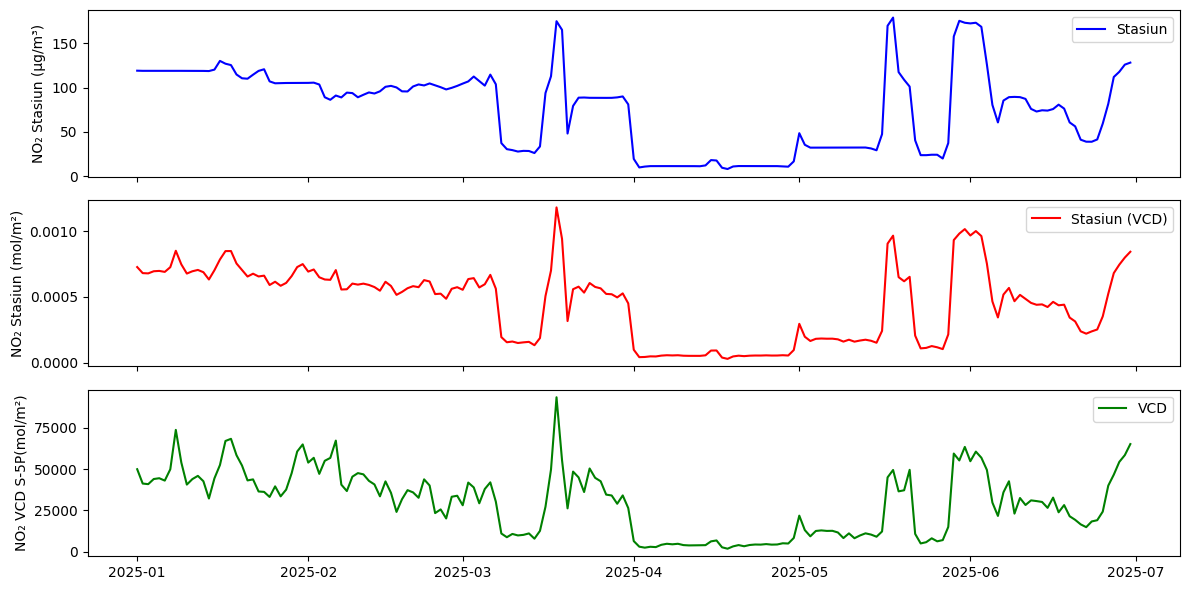

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df.index, df['no2_station_smooth'], color='blue', label='Stasiun')
axes[0].set_ylabel('NO₂ Stasiun (μg/m³)')
axes[0].legend()

axes[1].plot(df.index, df['no2_station_vcd_mol_m2'], color='red', label='Stasiun (VCD)')
axes[1].set_ylabel('NO₂ Stasiun (mol/m²)')
axes[1].legend()

axes[2].plot(df.index, df['no2_station_correction'], color='green', label='VCD')
axes[2].set_ylabel('NO₂ VCD S-5P(mol/m²)')
axes[2].legend()

plt.tight_layout()
plt.show()

# **VCD and Meteorology**

In [38]:

df_meteorology = pd.merge(
    no2_station['no2_station_smooth'],
    no2_vcd[['no2_vcd_filled', 'pb', 'ws', 'temp', 'wd', 'tp', 'sr']],
    left_index=True, right_index=True
).dropna()




In [39]:
# correlation analysis
corr_matrix = df_meteorology.corr(method='spearman')
print("Matriks Korelasi Spearman:")
print(corr_matrix)

Matriks Korelasi Spearman:
                    no2_station_smooth  no2_vcd_filled        pb        ws  \
no2_station_smooth            1.000000       -0.078744  0.154498  0.361949   
no2_vcd_filled               -0.078744        1.000000  0.043111 -0.004365   
pb                            0.154498        0.043111  1.000000  0.694556   
ws                            0.361949       -0.004365  0.694556  1.000000   
temp                         -0.129322        0.052528  0.227760 -0.038290   
wd                           -0.033404        0.072097  0.058875 -0.076500   
tp                            0.147073       -0.003412 -0.296127  0.126218   
sr                           -0.244808        0.081882  0.300484 -0.162392   

                        temp        wd        tp        sr  
no2_station_smooth -0.129322 -0.033404  0.147073 -0.244808  
no2_vcd_filled      0.052528  0.072097 -0.003412  0.081882  
pb                  0.227760  0.058875 -0.296127  0.300484  
ws                 -0.0382

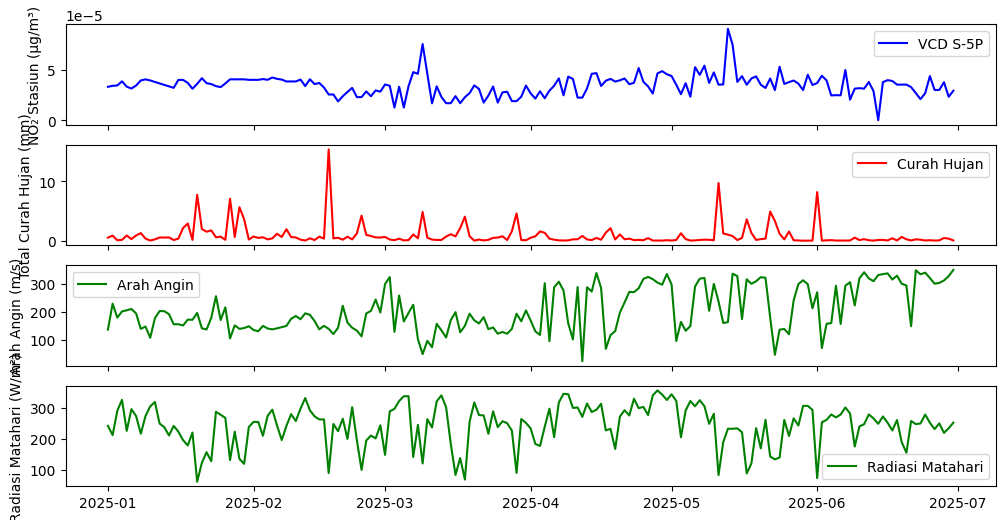

In [46]:
# comparison vcd and meteorological parameters
fig, axes = plt.subplots(4, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df_meteorology.index, df_meteorology['no2_vcd_filled'], color='blue', label='VCD S-5P')
axes[0].set_ylabel('NO₂ Stasiun (μg/m³)')
axes[0].legend()

axes[1].plot(df_meteorology.index, df_meteorology['tp'], color='red', label='Curah Hujan')
axes[1].set_ylabel('Total Curah Hujan (mm)')
axes[1].legend()

axes[2].plot(df_meteorology.index, df_meteorology['wd'], color='green', label='Arah Angin')
axes[2].set_ylabel('Arah Angin (m/s)')
axes[2].legend()


axes[3].plot(df_meteorology.index, df_meteorology['sr'], color='green', label='Radiasi Matahari')
axes[3].set_ylabel('Radiasi Matahari (W/m²)')
axes[3].legend()

# **Mean Per Month Analysis**

C:\Users\nuryabilla utami\AppData\Local\Temp\ipykernel_27252\1853607841.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_month = df.resample('M').mean()


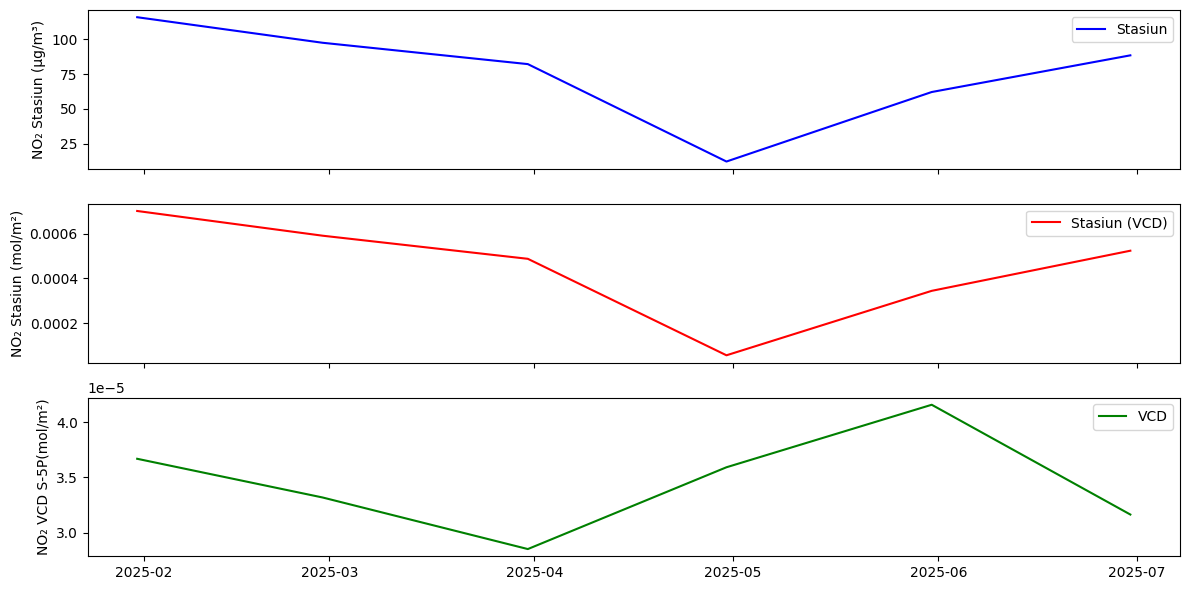

In [12]:
df_month = df.resample('M').mean()
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
axes[0].plot(df_month.index, df_month['no2_station_smooth'], color='blue', label='Stasiun')
axes[0].set_ylabel('NO₂ Stasiun (μg/m³)')
axes[0].legend()

axes[1].plot(df_month.index, df_month['no2_station_vcd_mol_m2'], color='red', label='Stasiun (VCD)')
axes[1].set_ylabel('NO₂ Stasiun (mol/m²)')
axes[1].legend()

axes[2].plot(df_month.index, df_month['no2_vcd_filled'], color='green', label='VCD')
axes[2].set_ylabel('NO₂ VCD S-5P(mol/m²)')
axes[2].legend()

plt.tight_layout()
plt.show()

# **K Factor**

In [18]:
# Hitung K faktor
df['K_calculated'] = (df['no2_station_vcd_mol_m2']) / (df['no2_station_smooth']) 

# Hitung standar deviasi untuk kedua variabel
std_station = df['no2_station_smooth'].std()
std_vcd = df['no2_station_vcd_mol_m2'].std()
print(f"Standar Deviasi NO₂ Stasiun: {std_station:.2f} μg/m³")
print(f"Standar Deviasi NO₂ Stasiun (VCD): {std_vcd:.2e} mol/m²")

# Hitung min max untuk kedua variabel
min_station = df['no2_station_smooth'].min()
max_station = df['no2_station_smooth'].max()
min_vcd = df['no2_station_vcd_mol_m2'].min()
max_vcd = df['no2_station_vcd_mol_m2'].max()
print(f"Min NO₂ Stasiun: {min_station:.2f} μg/m³")
print(f"Max NO₂ Stasiun: {max_station:.2f} μg/m³")
print(f"Min NO₂ Stasiun (VCD): {min_vcd:.2e} mol/m²")
print(f"Max NO₂ Stasiun (VCD): {max_vcd:.2e} mol/m²")

Standar Deviasi NO₂ Stasiun: 45.48 μg/m³
Standar Deviasi NO₂ Stasiun (VCD): 2.79e-04 mol/m²
Min NO₂ Stasiun: 8.21 μg/m³
Max NO₂ Stasiun: 179.12 μg/m³
Min NO₂ Stasiun (VCD): 3.00e-05 mol/m²
Max NO₂ Stasiun (VCD): 1.18e-03 mol/m²


In [19]:
print(df['K_calculated'].describe())

# hitung variansi k
var_k = df['K_calculated'].var()
print(f"Variansi K: {var_k:.2e}")

count    1.810000e+02
mean     5.656833e-06
std      6.721093e-07
min      3.649221e-06
25%      5.220577e-06
50%      5.695719e-06
75%      6.030766e-06
max      7.729915e-06
Name: K_calculated, dtype: float64
Variansi K: 4.52e-13


In [20]:
print(df[['no2_station_smooth', 'no2_station_vcd_mol_m2', 'no2_vcd_filled']])

df_vcd = df[['no2_vcd_filled', 'no2_station_smooth', 'no2_station_vcd_mol_m2']].copy()
# download data untuk analisis korelasi
df_vcd.to_excel(os.path.join(output_path, 'no2_station_vcd_correlation_analysis.xlsx'), index=True)


            no2_station_smooth  no2_station_vcd_mol_m2  no2_vcd_filled
time                                                                  
2025-01-01          119.179311                0.000727        0.000033
2025-01-02          119.013596                0.000681        0.000034
2025-01-03          118.994996                0.000679        0.000034
2025-01-04          118.998705                0.000696        0.000039
2025-01-05          119.000001                0.000698        0.000033
...                        ...                     ...             ...
2025-06-26           81.793226                0.000525        0.000030
2025-06-27          112.054100                0.000681        0.000030
2025-06-28          117.928547                0.000746        0.000038
2025-06-29          126.001963                0.000799        0.000023
2025-06-30          128.288790                0.000844        0.000029

[181 rows x 3 columns]


In [34]:
# Hitung min max untuk kedua variabel
min_vcd_satelit = df['no2_vcd_filled'].min()
max_vcd_satelit = df['no2_vcd_filled'].max()
min_vcd = df['no2_station_vcd_mol_m2'].min()
max_vcd = df['no2_station_vcd_mol_m2'].max()
print(f"Min NO₂ Satelit (VCD): {min_vcd_satelit:.3e} mol/m²")
print(f"Max NO₂ Satelit (VCD): {max_vcd_satelit:.3e} mol/m²")
print(f"Min NO₂ Stasiun (VCD): {min_vcd:.3e} mol/m²")
print(f"Max NO₂ Stasiun (VCD): {max_vcd:.3e} mol/m²")

Min NO₂ Satelit (VCD): 0.000e+00 mol/m²
Max NO₂ Satelit (VCD): 9.068e-05 mol/m²
Min NO₂ Stasiun (VCD): 2.996e-05 mol/m²
Max NO₂ Stasiun (VCD): 1.180e-03 mol/m²


In [21]:
# Cek nilai anomali di stasiun
print(df[df['no2_station_vcd_mol_m2'] < 10])

# Cek apakah ada nilai 0 atau sangat kecil
print(f"Nilai < 10 μg/m³: {(df['no2_station_vcd_mol_m2'] < 10).sum()} data")
print(f"Nilai = 0        : {(df['no2_station_vcd_mol_m2'] == 0).sum()} data")

# Cek periode Maret 2025
print(df['2025-03-01':'2025-03-31'])

            no2_station_smooth  no2_vcd_filled          pb     pb_km  \
time                                                                   
2025-01-01          119.179311        0.000033  418.524353  0.418524   
2025-01-02          119.013596        0.000034  346.394928  0.346395   
2025-01-03          118.994996        0.000034  343.399597  0.343400   
2025-01-04          118.998705        0.000039  369.372681  0.369373   
2025-01-05          119.000001        0.000033  373.431732  0.373432   
...                        ...             ...         ...       ...   
2025-06-26           81.793226        0.000030  488.874084  0.488874   
2025-06-27          112.054100        0.000030  415.720917  0.415721   
2025-06-28          117.928547        0.000038  460.405426  0.460405   
2025-06-29          126.001963        0.000023  463.304962  0.463305   
2025-06-30          128.288790        0.000029  507.067902  0.507068   

            no2_station_vcd  no2_station_vcd_mol_m2  K_calculat

# **Spike and Plot Time Series**

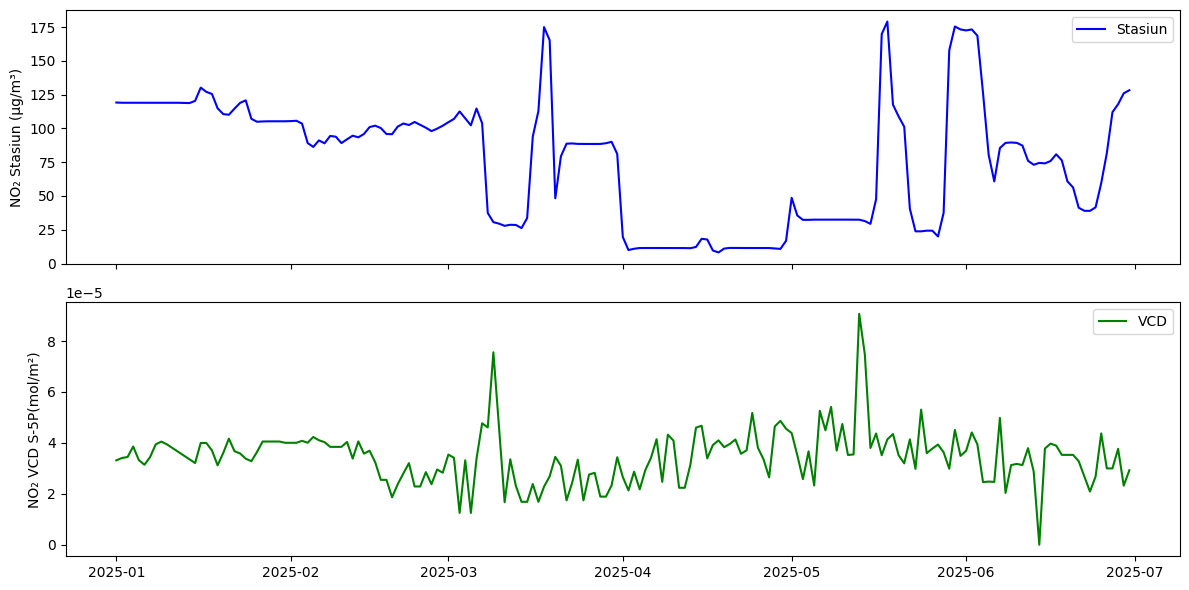

In [40]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df.index, df['no2_station_smooth'], color='blue', label='Stasiun')
axes[0].set_ylabel('NO₂ Stasiun (μg/m³)')
axes[0].legend()

axes[1].plot(df.index, df['no2_vcd_filled'], color='green', label='VCD')
axes[1].set_ylabel('NO₂ VCD S-5P(mol/m²)')
axes[1].legend()

plt.tight_layout()
plt.show()

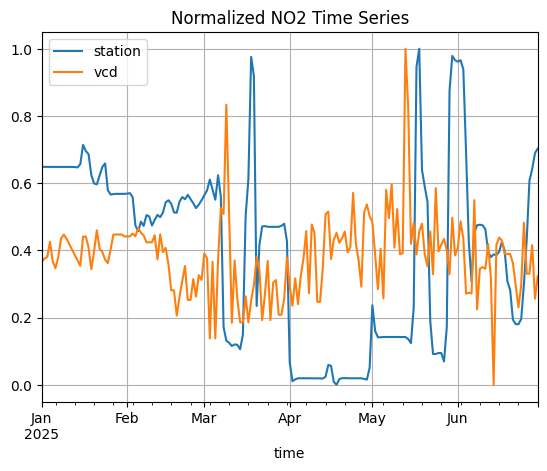

In [16]:
# Normalisasi data 

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_plot = pd.concat([
    df['no2_station_smooth'],
    df['no2_vcd_filled']
], axis=1).dropna()

df_plot_scaled = pd.DataFrame(
    scaler.fit_transform(df_plot),
    index=df_plot.index,
    columns=['station', 'vcd']
)

df_plot_scaled.plot(title="Normalized NO2 Time Series")
plt.grid()
plt.show()

In [17]:
ts = df['no2_station_smooth'].dropna()

threshold = ts.mean() + 2 * ts.std()

spikes = ts[ts > threshold]

print(spikes)

time
2025-03-18    175.013897
2025-05-17    169.836128
2025-05-18    179.123101
2025-05-30    175.468656
2025-05-31    173.267873
2025-06-01    172.540913
2025-06-02    173.279362
2025-06-03    168.656540
Name: no2_station_smooth, dtype: float64


In [ ]:
tv = df['no2_vcd_filled'].dropna()

threshold = tv.mean() + 2 * tv.std()

spikes_vcd = tv[tv > threshold]

print(spikes_vcd)

time
2025-03-09    0.000076
2025-05-13    0.000091
2025-05-14    0.000075
Name: no2_vcd_filled, dtype: float64


# **Korelasi NO2 Stasiun vs NO2 VCD**

In [35]:
# Korelasi
from scipy import stats
pearson_r,  p_pearson  = stats.pearsonr(df['no2_station_smooth'], df['no2_vcd_filled'])
spearman_r, p_spearman = stats.spearmanr(df['no2_station_smooth'], df['no2_vcd_filled'])

print(f"\n=== Korelasi ===")
print(f"Pearson  r : {pearson_r:.4f}  (p={p_pearson:.4f})")
print(f"Spearman ρ : {spearman_r:.4f}  (p={p_spearman:.4f})")



=== Korelasi ===
Pearson  r : -0.1371  (p=0.0658)
Spearman ρ : -0.0787  (p=0.2920)


In [12]:
# Pearson  r = -0.073  → p = 0.329  (p >> 0.05, tidak signifikan)
# Spearman ρ =  0.022  → p = 0.771  (p >> 0.05, tidak signifikan)
# Pearson  r = -0.073  (negatif lemah)
# Spearman ρ = +0.022  (positif lemah)

# "Korelasi antara NO₂ VCD dan NO₂ stasiun permukaan sangat lemah dan tidak signifikan secara statistik 
# (Pearson r = −0.073, p = 0.329; Spearman ρ = 0.022, p = 0.771), sehingga kalibrasi langsung tidak dilakukan. 
# Perbedaan ini mencerminkan ketidaksesuaian skala spasial dan fisik antara pengukuran kolom vertikal satelit 
# dan konsentrasi permukaan titik."

In [36]:
# Pisah per periode untuk lihat mana yang bermasalah
periods = {
    'Jan' : ('2025-01-01', '2025-01-31'),
    'Feb'   : ('2025-02-01', '2025-02-28'),
    'Mar'     : ('2025-03-01', '2025-03-31'),
    'Apr'     : ('2025-04-01', '2025-04-30'),
    'Mei' : ('2025-05-01', '2025-05-31'),
    'Jun' : ('2025-06-01', '2025-06-30')    
}

for period, (start, end) in periods.items():
    subset = df[start:end].dropna()
    if len(subset) > 5:
        r, p = stats.pearsonr(subset['no2_station_smooth'], subset['no2_vcd_filled'])
        print(f"{period}: r={r:.3f} (p={p:.3f}) n={len(subset)}")

Jan: r=-0.254 (p=0.167) n=31
Feb: r=-0.446 (p=0.017) n=28
Mar: r=-0.245 (p=0.183) n=31
Apr: r=0.058 (p=0.763) n=30
Mei: r=-0.172 (p=0.356) n=31
Jun: r=0.225 (p=0.233) n=30


# **Anomali Z-Score**

In [14]:
# Bandingkan tren temporal, bukan nilai absolut
# Normalisasi keduanya ke anomali (z-score)
df['station_anomaly']  = (df['no2_station_vcd_mol_m2'] - df['no2_station_vcd_mol_m2'].mean()) / df['no2_station_vcd_mol_m2'].std()
df['satelit_anomaly']  = (df['no2_vcd_filled'] - df['no2_vcd_filled'].mean()) / df['no2_vcd_filled'].std()

r_anom, p_anom = stats.pearsonr(df['station_anomaly'], df['satelit_anomaly'])
print(f"Korelasi anomali: r={r_anom:.4f} (p={p_anom:.4f})")

Korelasi anomali: r=-0.1314 (p=0.0778)


# **Regresi Linear**

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Copy dataframe
df_master = df.copy()


# Drop NaN
df_clean = df_master[['no2_station_smooth', 'no2_vcd_filled']].dropna()

# Definisikan X dan Y
X = df_clean[['no2_station_smooth']].values
y = df_clean['no2_vcd_filled'].values

# Model regresi
model = LinearRegression()
model.fit(X, y)

# Prediksi
y_pred = model.predict(X)

# Evaluasi
r2 = r2_score(y, y_pred)
slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (a): {slope}")
print(f"Intercept (b): {intercept}")
print(f"R^2 Score: {r2}")

Slope (a): -3.182049625294916e-08
Intercept (b): 3.704978302140414e-05
R^2 Score: 0.018785056508381914


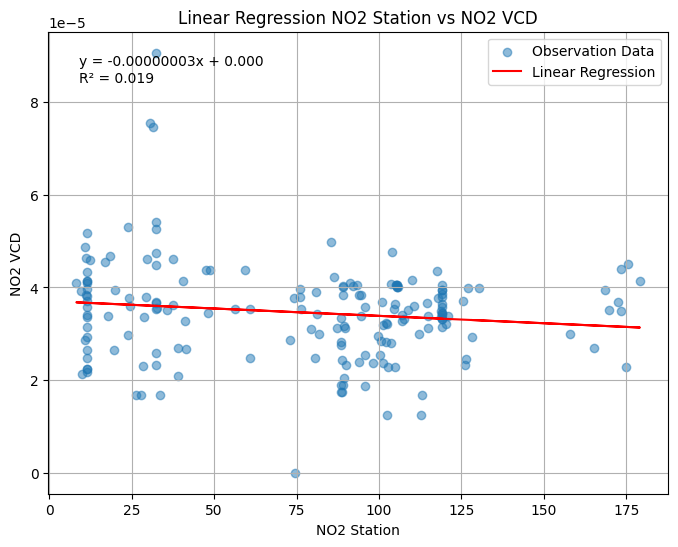

In [26]:
plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(X, y, alpha=0.5, label='Observation Data')

# Garis regresi
plt.plot(X, y_pred, color='red', label='Linear Regression')

# Label
plt.xlabel('NO2 Station')
plt.ylabel('NO2 VCD')
plt.title('Linear Regression NO2 Station vs NO2 VCD')

# Tambah persamaan di plot
plt.text(
    0.05, 0.95,
    f'y = {slope:.8f}x + {intercept:.3f}\nR² = {r2:.3f}',
    transform=plt.gca().transAxes,
    verticalalignment='top'
)

plt.legend()
plt.grid()
plt.show()

# **Regresi Log Transform**

R2 (log-log): 0.011957984985976222
y = -0.034x + -10.580


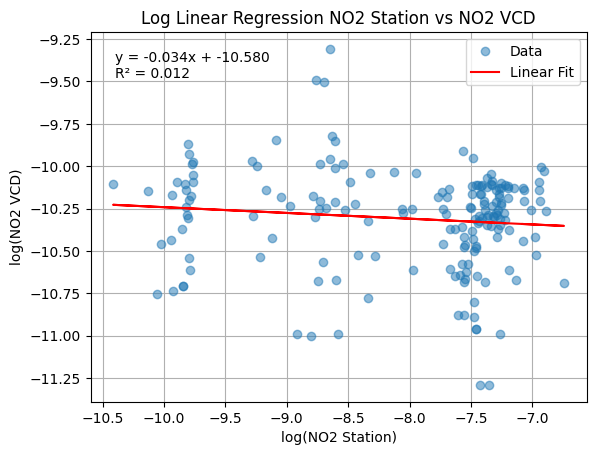

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Copy & clean
df_clean = df_master[['no2_station_vcd_mol_m2', 'no2_vcd_filled']].dropna().copy()

# Hapus nilai <= 0 (karena log)
df_clean = df_clean[(df_clean > 0).all(axis=1)]

# Log transform
df_clean['log_station'] = np.log(df_clean['no2_station_vcd_mol_m2'])
df_clean['log_vol'] = np.log(df_clean['no2_vcd_filled'])

# X dan y
X = df_clean[['log_station']].values
y = df_clean['log_vol'].values

# Model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Evaluasi
r2 = r2_score(y, y_pred)

print(f"R2 (log-log): {r2}")
print(f"y = {model.coef_[0]:.3f}x + {model.intercept_:.3f}")
plt.plot(X, y, 'o', alpha=0.5, label='Data')
plt.plot(X, y_pred, color='red', label='Linear Fit')
plt.xlabel('log(NO2 Station)')
plt.ylabel('log(NO2 VCD)')
plt.title('Log Linear Regression NO2 Station vs NO2 VCD')   
plt.text(
    0.05, 0.95,
    f'y = {model.coef_[0]:.3f}x + {model.intercept_:.3f}\nR² = {r2:.3f}',
    transform=plt.gca().transAxes,
    verticalalignment='top'
)

plt.legend()
plt.grid()
plt.show()

"Analisis korelasi antara NO₂ VCD satelit dan konsentrasi 
NO₂ permukaan dari stasiun pemantauan menunjukkan korelasi 
yang sangat lemah (r = -0.07, p > 0.05), konsisten dengan 
studi sebelumnya yang melaporkan rendahnya korelasi antara 
kedua variabel ini pada skala titik (misal: Lamsal et al., 
2008; Novotny et al., 2011). 

Perbedaan ini disebabkan oleh:
(1) perbedaan representasi spasial antara pengukuran kolom 
    vertikal satelit (~3.5 × 5.5 km²) dan pengukuran titik 
    stasiun permukaan,
(2) perbedaan fisik antara konsentrasi NO₂ permukaan dan 
    kolom vertikal atmosfer yang mencakup seluruh lapisan 
    troposfer, dan  
(3) pengaruh kondisi meteorologi lokal terhadap dispersi 
    NO₂ permukaan yang tidak tercermin dalam data satelit.

Oleh karena itu, kalibrasi langsung antara NO₂ VCD dan 
NO₂ stasiun tidak dilakukan. NO₂ VCD digunakan sebagai 
proksi distribusi spasial polusi NO₂ relatif."

In [27]:
# Korelasi per musim/periode
# Sudah terbukti Jan-Feb: r=+0.275 ✅
# Laporkan bahwa satelit valid untuk periode tertentu

# Atau bandingkan ranking/anomali bulanan
monthly_station = df['no2_station_vcd_mol_m2'].resample('ME').mean()
monthly_satelit = df['no2_vcd_filled'].resample('ME').mean()

r_monthly, p_monthly = stats.spearmanr(monthly_station, monthly_satelit)
print(f"Korelasi bulanan: r={r_monthly:.4f} (p={p_monthly:.4f})")

Korelasi bulanan: r=-0.0857 (p=0.8717)


Referensi yang bisa dikutip

Lamsal et al. (2008) — Ground-level nitrogen dioxide concentrations inferred from the satellite-borne Ozone Monitoring Instrument
Novotny et al. (2011) — National satellite-based land-use regression: NO₂ in the United States
Li et al. (2019) — paper RF-STK yang kamu pakai, juga menyebut limitasi ini